In [2]:
import sys; sys.path.append("../scripts")
import pandas as pd
from pathlib import Path
from dffh import (load_dffh_suburb_panel, coverage_filter, growth_cagr,
                  area_to_suburbs, make_suburb_key, AREA_ALIASES, yoy_growth)

RAW = Path("../data/raw")
SUBURB_FILE = next(RAW.glob("Moving annual*.xlsx"))
LGA_FILE    = next(RAW.glob("quarterly-median*.xlsx"))

xl = pd.ExcelFile(SUBURB_FILE)
print(xl.sheet_names)

['1 bedroom flat', '2 bedroom flat', '3 bedroom flat', '2 bedroom house', '3 bedroom house', '4 bedroom house', 'All properties']


In [3]:
panel = load_dffh_suburb_panel(SUBURB_FILE)

print(panel.shape)
print(panel.head())
print(f"areas: {panel.area.nunique()} | types: {panel.property_type.nunique()}")
print(f"quarters: {panel.quarter.min()} -> {panel.quarter.max()}")
print(f"missing medians: {panel.median_rent.isna().mean():.1%}")

(105266, 6)
            region                                   area   property_type  \
0  Inner Melbourne  Albert Park-Middle Park-West St Kilda  1 bedroom flat   
1  Inner Melbourne  Albert Park-Middle Park-West St Kilda  1 bedroom flat   
2  Inner Melbourne  Albert Park-Middle Park-West St Kilda  1 bedroom flat   
3  Inner Melbourne  Albert Park-Middle Park-West St Kilda  1 bedroom flat   
4  Inner Melbourne  Albert Park-Middle Park-West St Kilda  1 bedroom flat   

  quarter  count  median_rent  
0  2000Q1  352.0        165.0  
1  2000Q2  347.0        165.0  
2  2000Q3  378.0        170.0  
3  2000Q4  369.0        175.0  
4  2001Q1  395.0        180.0  
areas: 146 | types: 7
quarters: 2000Q1 -> 2025Q3
missing medians: 3.7%


In [4]:
pc = pd.read_csv(RAW / "postcodes.csv")
pc["suburb_u"] = pc.suburb.str.upper().str.strip()
pc = pc[["suburb_u", "postcode"]].drop_duplicates("suburb_u")

xw = area_to_suburbs(panel.area.unique())
xw["suburb_u"] = xw.suburb.str.upper().str.strip()
xw = xw.merge(pc, on="suburb_u", how="left")
xw["suburb_key"] = [make_suburb_key(s, p) if pd.notna(p) else None
                    for s, p in zip(xw.suburb, xw.postcode)]

print(f"{xw.suburb_key.notna().sum()}/{len(xw)} mapped")
print(xw[xw.suburb_key.isna()][["dffh_area", "suburb"]])

210/214 mapped
                           dffh_area           suburb
60   Dandenong North-Endeavour Hills  Dandenong North
86           Flora Hill-Bendigo East       Flora Hill
87           Flora Hill-Bendigo East     Bendigo East
211                     Yarra Ranges     Yarra Ranges


In [5]:
UNMAPPED_NOTES = {
    "Dandenong North": "absent from Domain listing data",
    "Flora Hill":      "Bendigo suburb; absent from Domain listing data",
    "Bendigo East":    "absent from Domain listing data",
    "Yarra Ranges":    "LGA, not a suburb; no single suburb equivalent",
}

In [6]:
from pathlib import Path
Path("../data/curated").mkdir(parents=True, exist_ok=True)
xw.to_csv("../data/curated/dffh_area_suburb_crosswalk.csv", index=False)
panel.to_parquet("../data/curated/dffh_rent_panel.parquet", index=False)
print("saved", xw.shape, panel.shape)

saved (214, 5) (105266, 6)


## Melbourne metropolitan median rent, 2000–2025

Count-weighted across the eight metropolitan DFFH regions. Weighting by bond
counts rather than taking a mean of medians, which isn't a meaningful statistic.
Shaded band marks the COVID period, a structural break that motivates the
2015–2025 window used for growth calculations.

195 -> 591


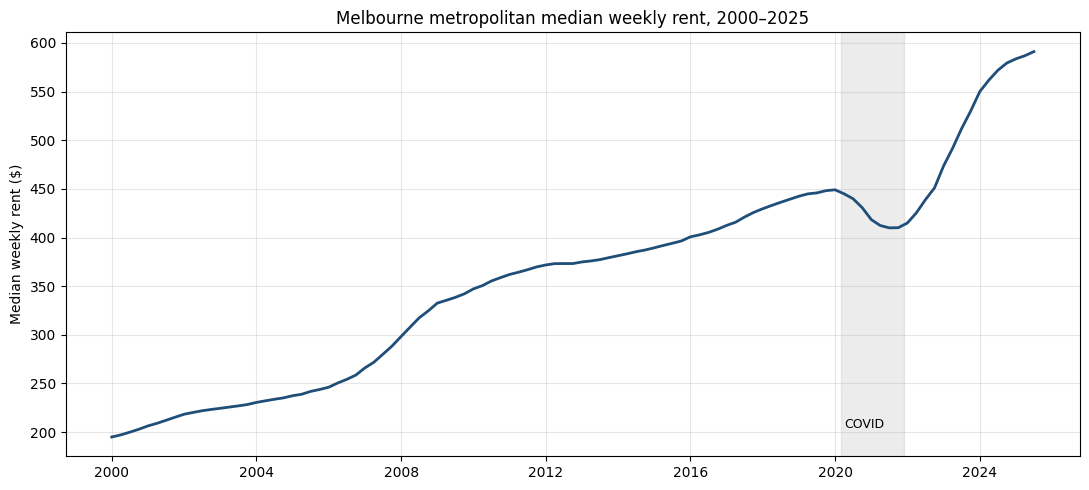

In [7]:
import matplotlib.pyplot as plt
from pathlib import Path
Path("../plots").mkdir(parents=True, exist_ok=True)

MELB = ["Inner Melbourne", "Inner Eastern Melbourne", "Southern Melbourne",
        "Outer Western Melbourne", "North Western Melbourne",
        "North Eastern Melbourne", "Outer Eastern Melbourne",
        "South Eastern Melbourne"]

s = panel[(panel.property_type == "All properties") & (panel.region.isin(MELB))]
ts = (s.groupby("quarter")
        .apply(lambda g: (g.median_rent * g["count"]).sum() / g["count"].sum(),
               include_groups=False))
ts.index = ts.index.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ts.index, ts.values, lw=2, color="#1f4e79")
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
           color="grey", alpha=0.15)
ax.text(pd.Timestamp("2020-04-01"), ts.min() * 1.05, "COVID", fontsize=9)
ax.set_title("Melbourne metropolitan median weekly rent, 2000–2025")
ax.set_ylabel("Median weekly rent ($)")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../plots/melbourne_median_rent.png", dpi=150)
print(f"{ts.iloc[0]:.0f} -> {ts.iloc[-1]:.0f}")

## Year-on-year growth series

The DFFH series is a *moving annual* median. Each quarter's figure covers the
trailing four quarters, so consecutive observations share 75% of their
underlying bonds. Differencing adjacent quarters would give artificially smooth,
heavily autocorrelated changes. Comparing the same quarter one year apart
(lag 4) gives non-overlapping windows.

This is the modelling input for the five-year forecast (Question 2).

In [8]:
growth = yoy_growth(panel)
growth.to_parquet("../data/curated/dffh_yoy_growth.parquet", index=False)
print(growth.shape, growth.area.nunique())

# Melbourne-wide picture
nat = growth.groupby("quarter").yoy_pct.median()
print(nat.loc[[pd.Period(q, "Q") for q in
               ["2008Q4", "2015Q3", "2020Q4", "2023Q3", "2025Q3"]]].round(2))

# volatility by area, post-2015
vol = (growth[growth.quarter >= pd.Period("2015Q3", "Q")]
       .groupby("area").yoy_pct.std().sort_values())
print("\nmost stable:\n", vol.head(3).round(2))
print("\nmost volatile:\n", vol.tail(3).round(2))

(14446, 6) 146
quarter
2008Q4    12.47
2015Q3     2.56
2020Q4     0.00
2023Q3    11.11
2025Q3     4.58
Freq: Q-DEC, Name: yoy_pct, dtype: float64

most stable:
 area
Belmont-Grovedale      2.07
Wendouree-Alfredton    2.24
Ballarat               2.31
Name: yoy_pct, dtype: float64

most volatile:
 area
Docklands          13.67
Southbank          13.81
CBD-St Kilda Rd    16.59
Name: yoy_pct, dtype: float64
